# Computer Vision Example

## Recognizing different items of clothing, trained from dataset containing 10 different types.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

print(tf.__version__)

# Fashion_MNIST_data = https://github.com/zalandoresearch/fashion-mnist
# Fashion_MNIST_image = https://github.com/zalandoresearch/fashion-mnist/raw/master/doc/img/fashion-mnist-sprite.png 

# loading tf.keras databases API
mnist = tf.keras.datasets.fashion_mnist

2.21.0


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
9
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130

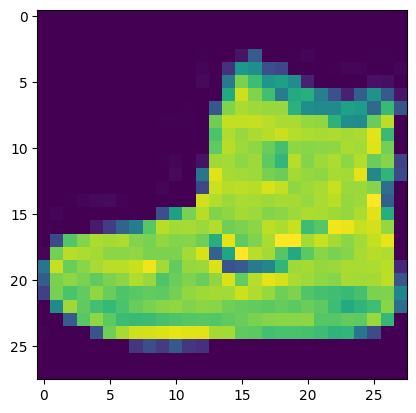

In [2]:
# train and test dataset
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()

# print a training image, and a training label
plt.imshow(training_images[0])
print(training_labels[0])
print(training_images[0])

In [3]:
# Normalization of values from (from 0 to 255) to (0 to 1)
training_images  = training_images / 255.0
test_images = test_images / 255.0

# Designing a model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(), 
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu), 
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

# Sequential defines a SEQUENCE of layers in the neural network
# Flatten just takes that square and turns it into a 1 dimensional set.
# Dense Adds a layer of neurons
# Each layer of neurons need an activation function to tell them what to do
# Relu effectively means "If X>0 return X, else return 0" 
# Softmax takes set of values and picks biggest one. [0.1, 0.1, 0.05, 0.1, 9.5, 0.1, 0.05, 0.05, 0.05] into [0,0,0,0,1,0,0,0,0] 

In [4]:
# Actually build it by compiling it with an optimizer and loss function
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Fitting your training data to your training labels
model.fit(training_images, training_labels, epochs=5)
# Accuracy on Train Data = 91

model.evaluate(test_images, test_labels)
# Accuracy on Test Dated = 88

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8244 - loss: 0.4992
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8646 - loss: 0.3767
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8767 - loss: 0.3386
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8855 - loss: 0.3149
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8910 - loss: 0.2985
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3747


[0.3747369647026062, 0.8644999861717224]

In [5]:
classifications = model.predict(test_images)
print(classifications[0]) # It's the probability that this item is each of the 10 classes
print(test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[2.7676635e-06 5.9758580e-09 1.3899630e-06 1.0062680e-06 8.2036667e-07
 4.3708934e-03 2.8336751e-06 5.5877403e-03 7.1227382e-04 9.8932016e-01]
9


In [6]:
# Question related to above CV example


# Experiment with different values for dense layer with 512 neurons
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(1024, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])
## Training takes longer, but is more accurate


# Removing the Flatten() layer 28,28 into a 784x1
model = tf.keras.models.Sequential([tf.keras.layers.Dense(64, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])
## Error in shape of data


# Trying training the network with 5
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(64, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])
## You get an error as soon as it finds an unexpected value. Another rule of thumb -- the number of neurons in the last layer should match the number of classes you are classifying for. In this case it's the digits 0-9, so there are 10 of them, hence you should have 10 neurons in your final layer.

# effects of additional layers in the network. What will happen if you add another layer between the one with 512 and the final layer with 10.
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(512, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(256, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])
## There isn't a significant impact -- because this is relatively simple data.


# Consider the impact of training for more or less epochs. Why do you think that would be the case? 
## Try 30 epochs -- you might see the loss value stops decreasing, and sometimes increases. This is a side effect of something called 'overfitting' 
